<a href="https://colab.research.google.com/github/athirasivadas94-glitch/EntriAssignments/blob/main/Assignment_DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

Objective: The main objective of this project is to design and implement a robust data preprocessing system that addresses common challenges such as missing values, outliers, inconsistent formatting, and noise.
By performing effective data preprocessing, the project aims to enhance the quality, reliability, and usefulness of the data for machine learning.

**1. Data Exploration:**

● Explore the data, list down the unique values in each feature and find its length.

● Perform the statistical analysis and renaming of the columns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [ ]:
# Load dataset
df = pd.read_csv("Employee.csv")
df.head(5)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [ ]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [ ]:
df.shape

(148, 6)

In [ ]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [ ]:
#Statistical Analysis
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [ ]:
# Unique values in each feature
# -------------------------------
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of unique values: 6

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of unique values: 29

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of unique values: 40

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of unique values: 11

Column: Country
Unique values: ['India']
Number of unique values: 1

Column: Gender
Unique values: [0 1]
Number of unique values: 2


In [ ]:
#Rename Columns
df.rename(columns={
    "Company": "company",
    "Age": "age",
    "Salary": "salary",
    "Place": "place",
    "Country": "country",
    "Gender": "gender"
}, inplace=True)

print("\nRenamed Columns:")
print(df.columns)


Renamed Columns:
Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')


**2. Data Cleaning:**

● Find the missing and inappropriate values, treat them appropriately.

● Remove all duplicate rows.

● Find the outliers.

● Replace the value 0 in age as NaN Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode) .

In [ ]:
# 1. Find missing & inappropriate values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64


In [ ]:
# Remove Duplicates
df.drop_duplicates()

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.0,Mumbai,India,0
143,TCS,33.0,9024.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


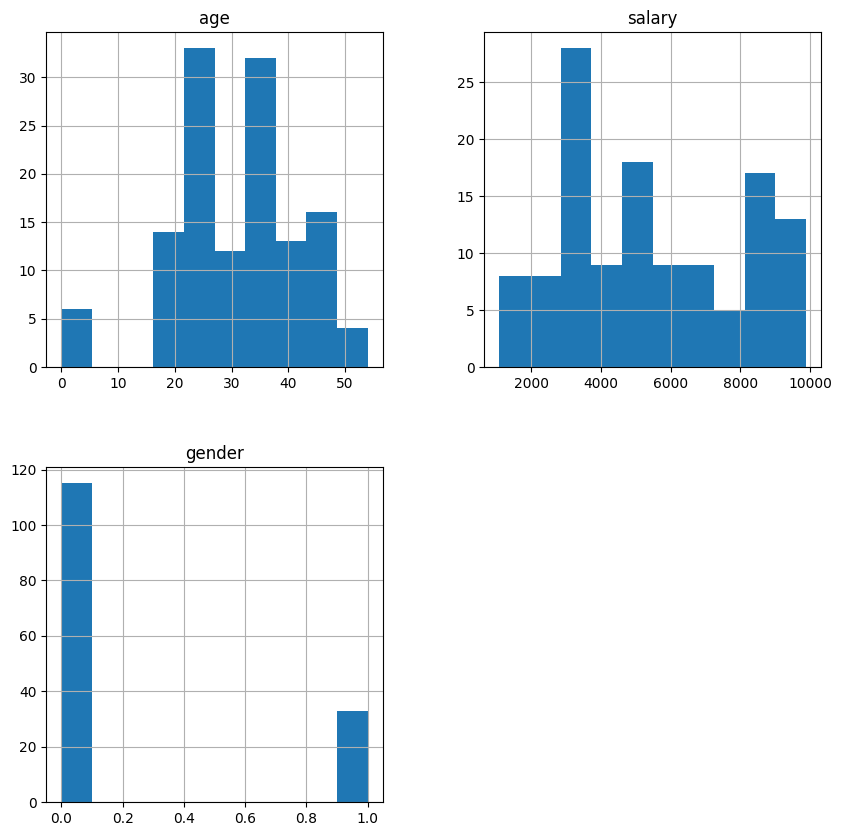

In [ ]:
df.hist(figsize=(10,10))
plt.show()

In [ ]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [ ]:
#Replace age = 0 with NaN
df['age'] = df['age'].replace(0, np.nan)

In [ ]:
df.head()

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [ ]:
#Fill Age and Salary with median
df['age'].fillna(df['age'].median(), inplace=True)
df['salary'].fillna(df['salary'].median(), inplace=True)

/tmp/ipython-input-3056817376.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipython-input-3056817376.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
company,8
age,0
salary,0
place,14
country,0
gender,0


In [ ]:
# Fill place(categorical column) with mode
#df['place'].fillna(df['place'].mode()[0], inplace=True)

In [ ]:
# Fill missing 'place' values by reassigning
df['place'] = df['place'].fillna(df['place'].mode()[0])

# Fill missing 'company' values by reassigning
df['company'] = df['company'].fillna(df['company'].mode()[0])

df.isnull().sum()

,0
company,0
age,0
salary,0
place,0
country,0
gender,0


<Axes: ylabel='age'>

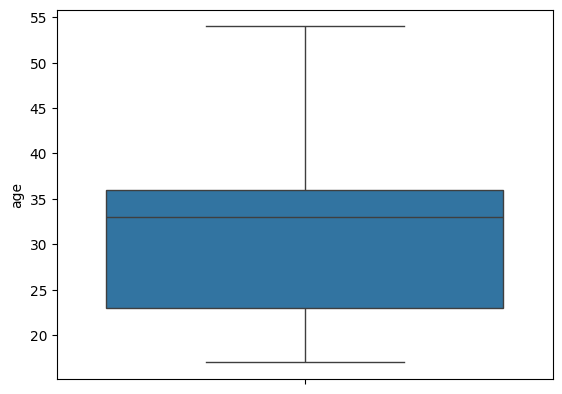

In [ ]:
sns.boxplot(data=df['age'])

<Axes: ylabel='salary'>

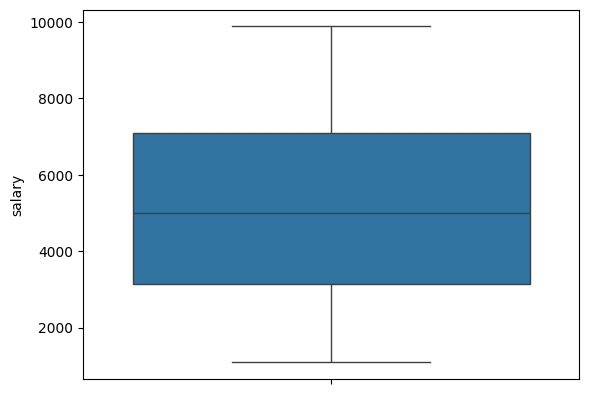

In [ ]:
sns.boxplot(data=df['salary'])

In [ ]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,5000.0,Chennai,India,0
1,Infosys,30.0,5000.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [ ]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

age_outliers = find_outliers('age')
salary_outliers = find_outliers('salary')

print("\nAge outliers:")
print(age_outliers)

print("\nSalary outliers:")
print(salary_outliers)


Age outliers:
Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []

Salary outliers:
Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []


No Outliers

In [ ]:
print("\nCleaned dataset:")
print(df.head())


Cleaned dataset:
   company   age  salary     place country  gender
0      TCS  20.0  5000.0   Chennai   India       0
1  Infosys  30.0  5000.0    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0


3. Data Analysis:

● Filter the data with age >40 and salary<5000 Plot the chart with age and salary

In [ ]:
#Filter: age > 40 and salary < 5000
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]

print("Filtered Data:")
print(filtered_df)

Filtered Data:
     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


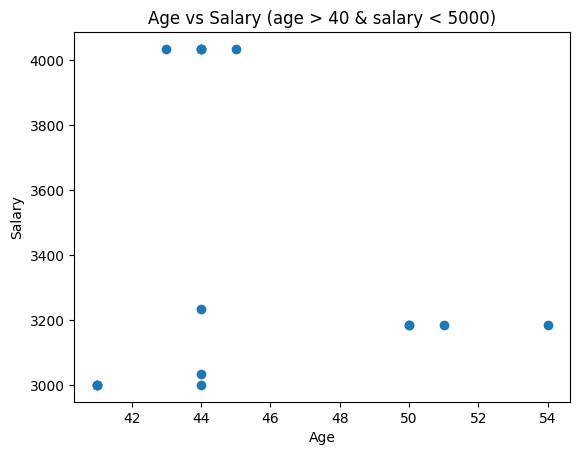

In [ ]:
plt.figure()
plt.scatter(filtered_df['age'], filtered_df['salary'])
plt.title("Age vs Salary (age > 40 & salary < 5000)")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

Count the number of people from each place and represent it visually

In [ ]:
#Count people from each place

place_counts = df['place'].value_counts()

print("\nPeople count by place:")
print(place_counts)




People count by place:
place
Mumbai        51
Calcutta      33
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


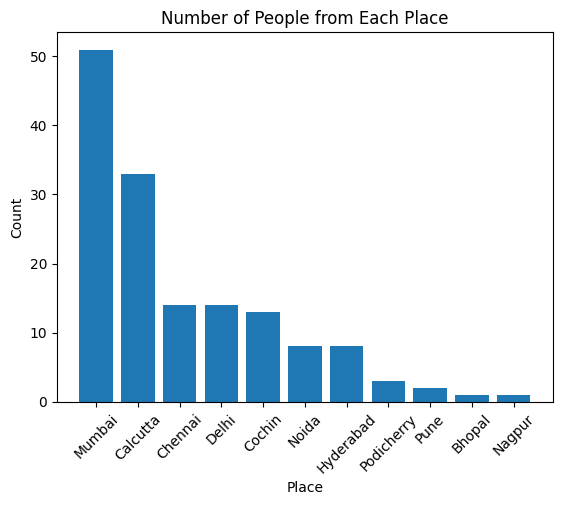

In [ ]:
# Bar chart
plt.figure()
plt.bar(place_counts.index, place_counts.values)
plt.title("Number of People from Each Place")
plt.xlabel("Place")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

4. Data Encoding:

● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [ ]:
# Create label encoder object
le = LabelEncoder()

# Label encoding categorical columns
df['company'] = le.fit_transform(df['company'])
df['place'] = le.fit_transform(df['place'])
df['country'] = le.fit_transform(df['country'])

print("Label Encoded Data:")
print(df.head())

Label Encoded Data:
   company   age  salary  place  country  gender
0        4  20.0  5000.0      2        0       0
1        2  30.0  5000.0      6        0       0
2        4  35.0  2300.0      1        0       0
3        2  40.0  3000.0      4        0       0
4        4  23.0  4000.0      6        0       0


5. Feature Scaling:

● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [ ]:
#Standard Scaling
x= df
sc = StandardScaler()
x_std = sc.fit_transform(x)

In [ ]:
x_std

array([[ 1.00048647, -1.47103329, -0.1114428 , -0.90153168,  0.        ,
        -0.53568323],
       [-0.23344684, -0.2581479 , -0.1114428 ,  0.74571139,  0.        ,
        -0.53568323],
       [ 1.00048647,  0.34829479, -1.26078838, -1.31334245,  0.        ,
        -0.53568323],
       [-0.23344684,  0.95473748, -0.96280989, -0.07791015,  0.        ,
        -0.53568323],
       [ 1.00048647, -1.10716767, -0.53712635,  0.74571139,  0.        ,
        -0.53568323],
       [-0.23344684,  0.10571771, -0.1114428 , -1.31334245,  0.        ,
        -0.53568323],
       [ 1.00048647,  0.10571771,  0.31424074, -0.90153168,  0.        ,
         1.86677489],
       [-0.23344684, -1.10716767,  0.73992429,  0.74571139,  0.        ,
         1.86677489],
       [ 1.00048647,  0.22700625,  1.16560784, -1.31334245,  0.        ,
         1.86677489],
       [-1.46738015,  1.56118017,  1.59129138, -0.07791015,  0.        ,
        -0.53568323],
       [-1.46738015, -1.10716767, -0.1114428 ,  0.

In [ ]:
x_std_df = pd.DataFrame(x_std, columns=x.columns)

print("Standard Scaled Data:")
print(x_std_df.head())

Standard Scaled Data:
    company       age    salary     place  country    gender
0  1.000486 -1.471033 -0.111443 -0.901532      0.0 -0.535683
1 -0.233447 -0.258148 -0.111443  0.745711      0.0 -0.535683
2  1.000486  0.348295 -1.260788 -1.313342      0.0 -0.535683
3 -0.233447  0.954737 -0.962810 -0.077910      0.0 -0.535683
4  1.000486 -1.107168 -0.537126  0.745711      0.0 -0.535683


In [ ]:
# Min-Max Scaling
y=df
scaler_minmax = MinMaxScaler()

y_minmax = scaler_minmax.fit_transform(y)

y_minmax_df = pd.DataFrame(y_minmax, columns=y.columns)

print("\nMin-Max Scaled Data:")
print(y_minmax_df.head())


Min-Max Scaled Data:
   company       age    salary  place  country  gender
0      0.8  0.081081  0.445089    0.2      0.0     0.0
1      0.4  0.351351  0.445089    0.6      0.0     0.0
2      0.8  0.486486  0.137817    0.1      0.0     0.0
3      0.4  0.621622  0.217480    0.4      0.0     0.0
4      0.8  0.162162  0.331285    0.6      0.0     0.0
